# Day 5 of ML 30-Days Challenge

# Task

Intro to Machine Learning: Understand the basic concepts: Supervised vs. Unsupervised Learning.

## Terminology: Features, Samples, Labels

In machine learning, it's important to understand some basic terminology:

*   **Samples (or instances):** These are the individual data points in your dataset. Each row in a dataset typically represents a sample.
*   **Features (or attributes):** These are the input variables or characteristics of each sample. Each column in a dataset (except for the label) typically represents a feature.
*   **Labels (or targets):** These are the output values or categories that you are trying to predict in supervised learning. In a dataset, this is typically a specific column that contains the known outcome for each sample.

**Example:**

In a dataset of houses:
*   Each **sample** is a single house.
*   The **features** might be the size of the house, the number of bedrooms, the location, etc.
*   The **label** (in a regression task) might be the selling price of the house, or the label (in a classification task) might be whether the house sold for above or below a certain price.

## Supervised Learning

Supervised learning is a type of machine learning where the algorithm learns from labeled data. This means the data used for training includes both the input features and the desired output labels. The goal is for the algorithm to learn a mapping from inputs to outputs so that it can make predictions on new, unseen data.

**Analogy:** Think of teaching a child to identify different animals by showing them pictures of animals and telling them the animal's name. The picture is the input, and the animal's name is the label. The child learns to associate the picture with the name, just like a supervised learning algorithm learns to associate input features with output labels.

It has two categories {not sure it's a *Type* or *Category* } :
- Classification
- Regression

### Classification

Classification is a supervised learning task where the goal is to predict a categorical label for a given input. This means the output of the model is a class or category.

**Examples:**
*   **Spam detection:** Classifying an email as "spam" or "not spam".
*   **Image recognition:** Identifying the object in an image (e.g., "cat", "dog", "bird").
*   **Medical diagnosis:** Classifying if a patient has a particular disease based on their symptoms.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Sample data: [Age, Salary] and label: 1 = Buy (True), 0 = Don't Buy (False)
X = np.array([
    [22, 20000],
    [25, 22000],
    [47, 47000],
    [52, 52000],
    [46, 49000],
    [56, 60000],
    [55, 58000],
    [60, 62000],
    [18, 18000],
    [30, 25000]
])
y = np.array([0, 0, 1, 1, 1, 1, 1, 1, 0, 0])  # 0 = No, 1 = Yes (True/False)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on new data
new_person = np.array([[40, 40000]])  # Age 40, salary 40k
pred = model.predict(new_person)
print("Prediction for new person (1=True/0=False):", pred[0])

Prediction for new person (1=True/0=False): 1


### Regression

Regression is a supervised learning task where the goal is to predict a continuous numerical value for a given input. Unlike classification, which predicts categories, regression predicts numbers.

**Examples:**
*   **House price prediction:** Predicting the selling price of a house based on its features (size, location, number of bedrooms, etc.).
*   **Stock price prediction:** Predicting the future price of a stock.
*   **Sales forecasting:** Predicting the sales of a product for the next quarter.

In [45]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Sample data [Height (cm), Age (years)]
X = np.array([
    [150, 18],
    [160, 20],
    [170, 22],
    [180, 25],
    [165, 30],
    [175, 28],
    [185, 35],
    [155, 24],
    [172, 33],
    [168, 21]
])

# Corresponding weight (kg)
y = np.array([50, 56, 65, 72, 68, 70, 78, 55, 75, 66])

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict new sample
new_person = np.array([[178, 26]])  # Height: 178 cm, Age: 26
predicted_weight = model.predict(new_person)
print(f"Predicted weight for person with height 178 cm and age 26: {predicted_weight[0]:.2f} kg")

Predicted weight for person with height 178 cm and age 26: 71.42 kg


## Unsupervised Learning

Unsupervised learning is a type of machine learning where the algorithm learns from unlabeled data. This means the data used for training does not have predefined output labels. The goal is for the algorithm to find patterns, structures, or relationships within the data on its own.

**Analogy:** Imagine giving a child a box of assorted toys and asking them to sort them into groups based on their similarities, without telling them what the groups should be (e.g., cars, blocks, dolls). The child has to figure out the categories themselves, just like an unsupervised learning algorithm finds patterns in data without labels.

It has two categories {again not sure it's a *Type* or *Category* } :
- Clustering
- Density estimation
- Dimensionality reduction (Visualization)

### Clustering

Clustering is an unsupervised learning task that involves grouping data points into clusters such that data points in the same cluster are more similar to each other than to those in other clusters.

**Applications:**
*   **Customer segmentation:** Grouping customers based on their purchasing behavior.
*   **Document analysis:** Grouping similar documents together.
*   **Anomaly detection:** Identifying unusual data points that don't fit into any cluster.

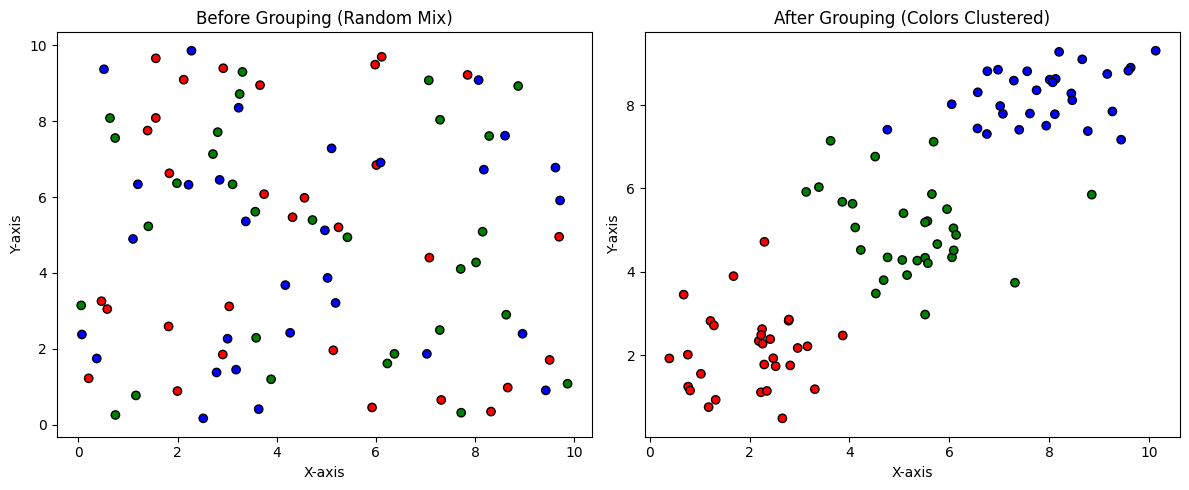

In [48]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Step 1: Create 3 groups of colored dots randomly scattered
colors = ['red', 'green', 'blue']
num_points_per_group = 30
X_random = []
color_labels = []

for color in colors:
    x = np.random.rand(num_points_per_group) * 10
    y = np.random.rand(num_points_per_group) * 10
    X_random.append(np.column_stack((x, y)))
    color_labels += [color] * num_points_per_group

X_random = np.vstack(X_random)

# Step 2: Create grouped versions of same color dots
centers = [(2, 2), (5, 5), (8, 8)]
X_grouped = []

for i, center in enumerate(centers):
    cx, cy = center
    x = np.random.randn(num_points_per_group) + cx
    y = np.random.randn(num_points_per_group) + cy
    X_grouped.append(np.column_stack((x, y)))

X_grouped = np.vstack(X_grouped)

# Step 3: Plot both side by side
plt.figure(figsize=(12, 5))

# Plot 1: Random positions (colors mixed)
plt.subplot(1, 2, 1)
plt.scatter(X_random[:, 0], X_random[:, 1], c=color_labels, edgecolor='black')
plt.title("Before Grouping (Random Mix)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

# Plot 2: Grouped by color
plt.subplot(1, 2, 2)
plt.scatter(X_grouped[:, 0], X_grouped[:, 1], c=color_labels, edgecolor='black')
plt.title("After Grouping (Colors Clustered)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

plt.tight_layout()
plt.show()


### Density Estimation

Density estimation is an unsupervised learning task that involves estimating the probability distribution of a dataset. It helps understand the structure of the data and can be used for tasks like anomaly detection or data generation.

**Applications:**
*   **Anomaly detection:** Identifying data points that have a low probability under the estimated distribution.
*   **Data generation:** Sampling new data points from the estimated distribution.
*   **Data visualization:** Understanding the shape and spread of the data.

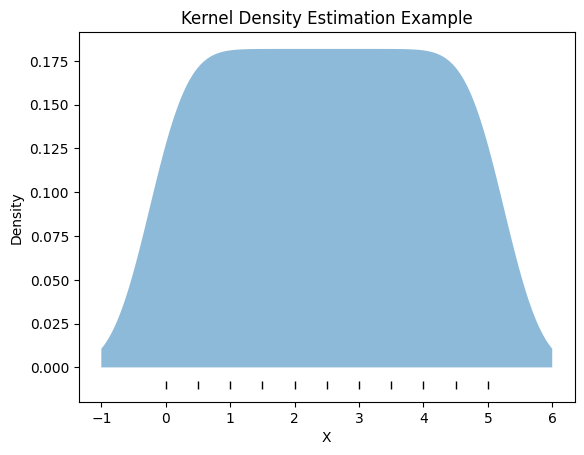

In [23]:
# Simple example of Density Estimation (Kernel Density Estimation)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# Generate sample data
X = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]).reshape(-1, 1)

# Create a Kernel Density Estimation model
kde = KernelDensity(kernel='gaussian', bandwidth=0.5)

# Train the model
kde.fit(X)

# Generate points for plotting the density
X_plot = np.linspace(-1, 6, 1000).reshape(-1, 1)
log_density = kde.score_samples(X_plot)

# Visualize the density
plt.fill_between(X_plot[:, 0], np.exp(log_density), alpha=0.5)
plt.plot(X[:, 0], np.full_like(X[:, 0], -0.01), '|k', markeredgewidth=1)
plt.xlabel("X")
plt.ylabel("Density")
plt.title("Kernel Density Estimation Example")
plt.show()

### Dimensionality Reduction (Visualization)

Dimensionality reduction is a technique used to reduce the number of features (variables) in a dataset while retaining as much of the important information as possible. This is particularly useful for visualization, as it allows us to plot high-dimensional data in 2 or 3 dimensions.

**Applications:**
*   **Data visualization:** Making high-dimensional data understandable by plotting it in lower dimensions.
*   **Noise reduction:** Removing irrelevant or redundant features that can obscure patterns.
*   **Improving model performance:** Reducing the number of features can sometimes lead to simpler models that are less prone to overfitting.

**And Yeah its not clustering as you can see in example**

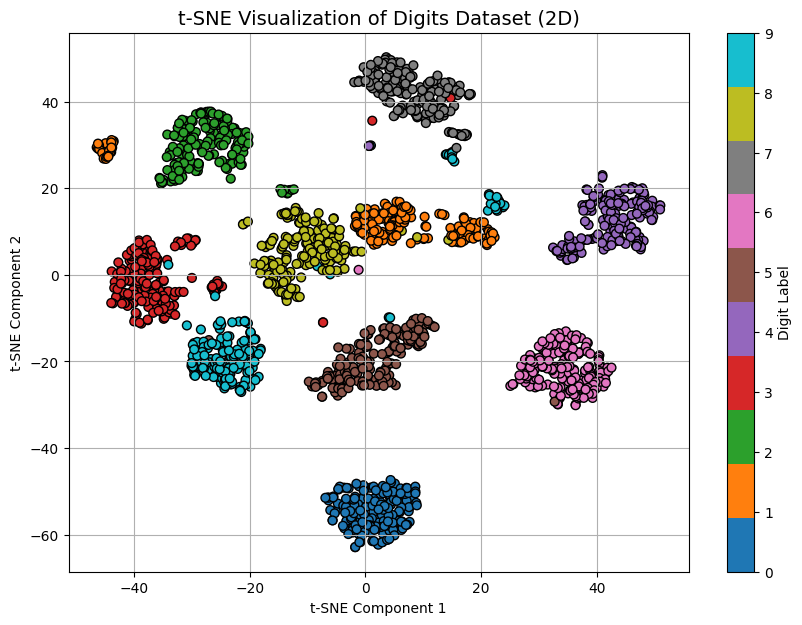

In [58]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

# Step 1: Load the dataset
digits = load_digits()
X = digits.data       # Shape: (1797, 64)
y = digits.target     # Digit labels: 0–9

# Step 2: Apply t-SNE for 2D reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X)

# Step 3: Plot the 2D representation
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', edgecolor='k', s=40)
plt.title("t-SNE Visualization of Digits Dataset (2D)", fontsize=14)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.grid(True)
plt.show()

## Training vs Testing Sets

In supervised machine learning, it is crucial to split your data into training and testing sets.

*   **Training Set:** This subset of the data is used to train the machine learning model. The model learns the relationship between the features and the labels from this data.
*   **Testing Set:** This independent subset of the data is used to evaluate the performance of the trained model on unseen data. This helps to assess how well the model generalizes to new examples and to detect overfitting.

It is important that the testing set is not used during the training process to get an unbiased evaluation of the model's performance.

In [54]:
# Example of splitting data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load a sample dataset (Iris dataset)
iris = load_iris()
X, y = iris.data, iris.target

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original data shape: {X.shape}")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Original data shape: (150, 4)
Training data shape: (120, 4)
Testing data shape: (30, 4)
